<a href="https://colab.research.google.com/github/Steph12333333/S/blob/main/Creditcardproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

KeyboardInterrupt: 

### Data Persistence with Google Drive

To avoid re-uploading your `creditcard.csv` file every time the Colab runtime restarts, you can store it in your Google Drive. By mounting your Google Drive in Colab, your files will be accessible directly from the `/content/drive` directory.

**Steps:**
1.  **Mount Google Drive:** Run the Python cell below. You will be prompted to authorize Colab to access your Google Drive.
2.  **Move your data:** Once mounted, you can manually move your `creditcard.csv` file to a suitable folder in your Google Drive (e.g., `My Drive/Colab Notebooks/data`).
3.  **Update file path:** Change the `pd.read_csv()` path in cell `0c4JIqf9X74p` to point to the new location in your Google Drive (e.g., `'/content/drive/MyDrive/Colab Notebooks/data/creditcard.csv'`).

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

print("Google Drive mounted. Now, move your 'creditcard.csv' file to your Drive and update the path in `pd.read_csv()` in cell 0c4JIqf9X74p.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted. Now, move your 'creditcard.csv' file to your Drive and update the path in `pd.read_csv()` in cell 0c4JIqf9X74p.


LOGISTIC REGRESSION

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

RANDOM_STATE = 55

df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/creditcard.csv")


print(df.head(10))

#seperate x and y
X= df.drop(columns=["Class"])
Y=df["Class"]

#look at the shape of the data
print(f"Shape of X is {X.shape}")
print(f"Shape of Y is {Y.shape}")


x_train, x_, y_train, y_= train_test_split(X, Y, test_size=0.4, random_state=1)


x_cv, x_test, y_cv, y_test = train_test_split(x_, y_, test_size=0.50, random_state=1)




scaler = StandardScaler()
x_trainorm=scaler.fit_transform(x_train)
x_cvnorm=scaler.transform(x_cv)
x_testnorm=scaler.transform(x_test)


model = LogisticRegression()

model.fit(x_trainorm,y_train)



from sklearn.metrics import log_loss

def calculate_log_loss(model, X, Y, dataset_name):
    """Calculates and prints the log loss for a classification model."""
    y_proba = model.predict_proba(X)

    # log_loss requires probabilities for the positive class (class 1)
    logloss_value = log_loss(Y, y_proba[:, 1])
    print(f"\n--- {dataset_name} Set Log Loss ---")
    print(f"Log Loss: {logloss_value:.4f}")

# Calculate Log Loss on Training Set
calculate_log_loss(model, x_trainorm, y_train, "Training")

# Calculate Log Loss on Cross-Validation Set
calculate_log_loss(model, x_cvnorm, y_cv, "Cross-Validation")

# Calculate Log Loss on Test Set
calculate_log_loss(model, x_testnorm, y_test, "Test")

print(f"The f1 score on training data is:{f1_score(y_train,model.predict(x_trainorm))}")

print(f"The f1 score on cv data is:{f1_score(y_cv,model.predict(x_cvnorm))}")

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   
5   2.0 -0.425966  0.960523  1.141109 -0.168252  0.420987 -0.029728  0.476201   
6   4.0  1.229658  0.141004  0.045371  1.202613  0.191881  0.272708 -0.005159   
7   7.0 -0.644269  1.417964  1.074380 -0.492199  0.948934  0.428118  1.120631   
8   7.0 -0.894286  0.286157 -0.113192 -0.271526  2.669599  3.721818  0.370145   
9   9.0 -0.338262  1.119593  1.044367 -0.222187  0.499361 -0.246761  0.651583   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -

DECISION TREE

TUNING SAMPLES


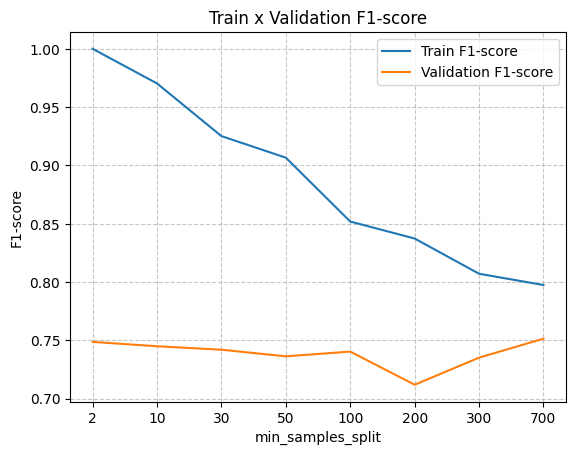

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score


min_samples_split_list = [2,10, 30, 50, 100, 200, 300, 700]
max_depth_list = [1,2, 3, 4, 8, 16, 32, 64, 128,256,None]

f1_list_train = []
f1_list_val = []

for min_samples_split in min_samples_split_list:

    model = DecisionTreeClassifier(min_samples_split = min_samples_split,
                                   random_state = RANDOM_STATE).fit(x_trainorm,y_train)
    predictions_train = model.predict(x_trainorm)
    predictions_val = model.predict(x_cvnorm)


    f1_train = f1_score(y_train, predictions_train)
    f1_val = f1_score(y_cv, predictions_val)
    f1_list_train.append(f1_train)
    f1_list_val.append(f1_val)

plt.title('Train x Validation F1-score')
plt.xlabel('min_samples_split')
plt.ylabel('F1-score')
plt.xticks(ticks = range(len(min_samples_split_list )),labels=min_samples_split_list)
plt.plot(f1_list_train)
plt.plot(f1_list_val)
plt.legend(['Train F1-score','Validation F1-score'])
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Tune depth for decision tree

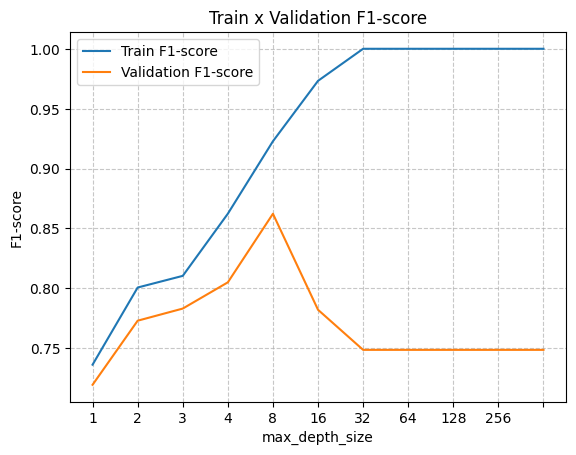

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt

RANDOM_STATE = 55

f1_list_train = []
f1_list_val = []

for max_depth in max_depth_list:
    model = DecisionTreeClassifier(max_depth= max_depth,
                                   random_state = RANDOM_STATE).fit(x_trainorm,y_train)
    predictions_train = model.predict(x_trainorm)
    predictions_val = model.predict(x_cvnorm)


    f1_train = f1_score(y_train, predictions_train)
    f1_val = f1_score(y_cv, predictions_val)
    f1_list_train.append(f1_train)
    f1_list_val.append(f1_val)


plt.title('Train x Validation F1-score')
plt.xlabel('max_depth_size')
plt.ylabel('F1-score')
plt.xticks(ticks = range(len(max_depth_list)),labels=max_depth_list)
plt.plot(f1_list_train)
plt.plot(f1_list_val)
plt.legend(['Train F1-score','Validation F1-score'])
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

Evaluate the models performance using F1 score

In [ ]:
modtee = DecisionTreeClassifier(max_depth=8, min_samples_split=700, random_state=RANDOM_STATE)
modtee.fit(x_trainorm, y_train)
print(f"The f1 score for the ideal decision tree algo is: {f1_score(y_train, modtee.predict(x_trainorm))}")

The f1 score for the ideal decision tree algo is: 0.7796052631578947


In [ ]:

predictions_cv_modtee = modtee.predict(x_cvnorm)
f1_cv_modtee = f1_score(y_cv, predictions_cv_modtee)
print(f"The f1 score for the ideal decision tree algo on the cross-validation set is: {f1_cv_modtee:.4f}")


The f1 score for the ideal decision tree algo on the cross-validation set is: 0.7861


Random forest classifier

TUNE MIN LIST

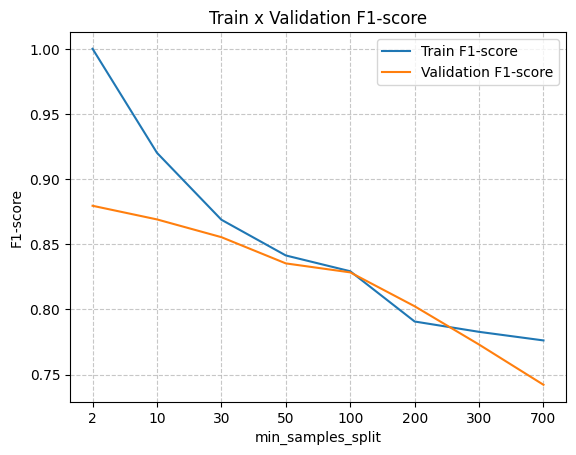

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
import math

f1_list_train = []
f1_list_val=[]

min_samples_split_list = [2,10, 30, 50, 100, 200, 300, 700]
max_depth_list = [1,2, 3, 4, 8, 16, 32, 64,None]
n_estimators_list = [10,50,100,500]
RANDOM_STATE = 55


for min_samples_split in min_samples_split_list:
    model = RandomForestClassifier(min_samples_split = min_samples_split,max_features=int(math.sqrt(30)),
                                   random_state = RANDOM_STATE).fit(x_trainorm,y_train)
    predictions_train = model.predict(x_trainorm)
    predictions_val = model.predict(x_cvnorm)


    f1_train = f1_score(y_train, predictions_train)
    f1_val = f1_score(y_cv, predictions_val)
    f1_list_train.append(f1_train)
    f1_list_val.append(f1_val)

plt.title('Train x Validation F1-score')
plt.xlabel('min_samples_split')
plt.ylabel('F1-score')
plt.xticks(ticks = range(len(min_samples_split_list )),labels=min_samples_split_list)
plt.plot(f1_list_train)
plt.plot(f1_list_val)
plt.legend(['Train F1-score','Validation F1-score'])
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

TUNE DEPTH FOR RANDOM FOREST

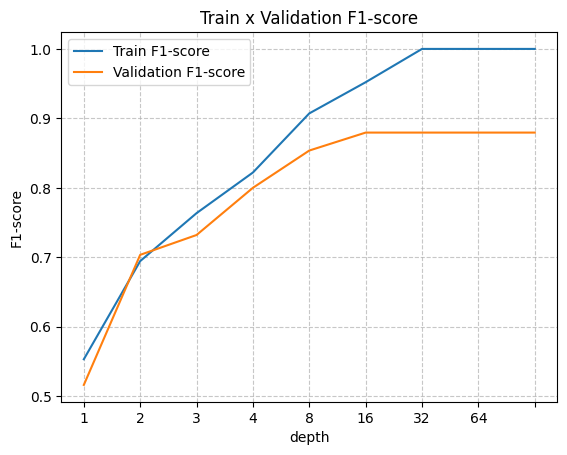

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score
import math

f1_list_train = []
f1_list_val = []

min_samples_split_list = [2,10, 30, 50, 100, 200, 300, 700]
max_depth_list = [1,2, 3, 4, 8, 16, 32, 64,None]
n_estimators_list = [10,50,100,500]
RANDOM_STATE = 55


for max_depth_1 in max_depth_list:

    model = RandomForestClassifier(max_depth=max_depth_1,max_features=int(math.sqrt(30)),
                                   random_state = RANDOM_STATE).fit(x_trainorm,y_train)
    predictions_train = model.predict(x_trainorm)
    predictions_val = model.predict(x_cvnorm)


    f1_train = f1_score(y_train, predictions_train)
    f1_val = f1_score(y_cv, predictions_val)
    f1_list_train.append(f1_train)
    f1_list_val.append(f1_val)

plt.title('Train x Validation F1-score')
plt.xlabel('depth')
plt.ylabel('F1-score')
plt.xticks(ticks = range(len(max_depth_list )),labels=max_depth_list)
plt.plot(f1_list_train)
plt.plot(f1_list_val)
plt.legend(['Train F1-score','Validation F1-score'])
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()



TUNE ESTIMATORS FOR RANDOM FOREST

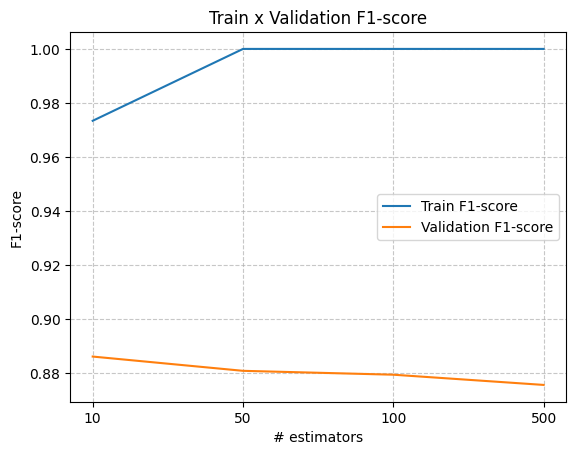

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

f1_list_train = []
f1_list_val = []

min_samples_split_list = [2,10, 30, 50, 100, 200, 300, 700]
max_depth_list = [1,2, 3, 4, 8, 16, 32, 64,None]
n_estimators_list = [10,50,100,500]
RANDOM_STATE = 55


for estimators_ in n_estimators_list:
    model = RandomForestClassifier(n_estimators=estimators_,max_features=int(math.sqrt(30)),
                                   random_state = RANDOM_STATE).fit(x_trainorm,y_train)
    predictions_train = model.predict(x_trainorm)
    predictions_val = model.predict(x_cvnorm)


    f1_train = f1_score(y_train, predictions_train)
    f1_val = f1_score(y_cv, predictions_val)
    f1_list_train.append(f1_train)
    f1_list_val.append(f1_val)

plt.title('Train x Validation F1-score')
plt.xlabel('# estimators')
plt.ylabel('F1-score')
plt.xticks(ticks = range(len( n_estimators_list)),labels=n_estimators_list)
plt.plot(f1_list_train)
plt.plot(f1_list_val)
plt.legend(['Train F1-score','Validation F1-score'])
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

COMPUTE F1 SCORE FOR FOREST

In [ ]:
randos = RandomForestClassifier(max_depth=8, min_samples_split=10, random_state=RANDOM_STATE, max_features=int(math.sqrt(30)),n_estimators=10)
randos.fit(x_trainorm, y_train)
print(f"The f1 score for the ideal randomforest algo is: {f1_score(y_train, randos.predict(x_trainorm))}")

The f1 score for the ideal randomforest algo is: 0.8939929328621908


In [ ]:

print(f"The f1 score for the ideal decision tree algoon the cv set is : {f1_score(y_cv,randos.predict(x_cvnorm))}")

The f1 score for the ideal decision tree algoon the cv set is : 0.8690476190476191


XG BOOST ALGO

In [ ]:
from xgboost import XGBClassifier


n=int(0.8*len(x_train))
X_train_fit, X_train_eval, y_train_fit, y_train_eval = x_trainorm[:n], x_trainorm[n:], y_train[:n], y_train[n:]



xgb_model = XGBClassifier(n_estimators = 500, learning_rate = 0.1,verbosity = 1, random_state = RANDOM_STATE,early_stopping_rounds = 30)
xgb_model.fit(X_train_fit,y_train_fit, eval_set = [(X_train_eval,y_train_eval)])

print(f"F1 score on the training set:{f1_score(y_train,xgb_model.predict(x_trainorm))}")

print(f"F1 score on the validation set set:{f1_score(y_cv,xgb_model.predict(x_cvnorm))}")

[0]	validation_0-logloss:0.01345
[1]	validation_0-logloss:0.01175
[2]	validation_0-logloss:0.01045
[3]	validation_0-logloss:0.00943
[4]	validation_0-logloss:0.00860
[5]	validation_0-logloss:0.00791
[6]	validation_0-logloss:0.00731
[7]	validation_0-logloss:0.00678
[8]	validation_0-logloss:0.00636
[9]	validation_0-logloss:0.00597
[10]	validation_0-logloss:0.00563
[11]	validation_0-logloss:0.00532
[12]	validation_0-logloss:0.00506
[13]	validation_0-logloss:0.00484
[14]	validation_0-logloss:0.00465
[15]	validation_0-logloss:0.00445
[16]	validation_0-logloss:0.00429
[17]	validation_0-logloss:0.00414
[18]	validation_0-logloss:0.00401
[19]	validation_0-logloss:0.00389
[20]	validation_0-logloss:0.00377
[21]	validation_0-logloss:0.00370
[22]	validation_0-logloss:0.00361
[23]	validation_0-logloss:0.00354
[24]	validation_0-logloss:0.00345
[25]	validation_0-logloss:0.00338
[26]	validation_0-logloss:0.00332
[27]	validation_0-logloss:0.00326
[28]	validation_0-logloss:0.00321
[29]	validation_0-loglos

Based on our observations the SGB Classifier yields the highest F1 score out of all the algorithm thus is the  better algo to use for this problem